--- SURFACE ROUGHNESS METRICS ---
High-Frequency Energy Ratio: 56.62%
(A higher % means more scuffs, scratches, and severe leather degradation)



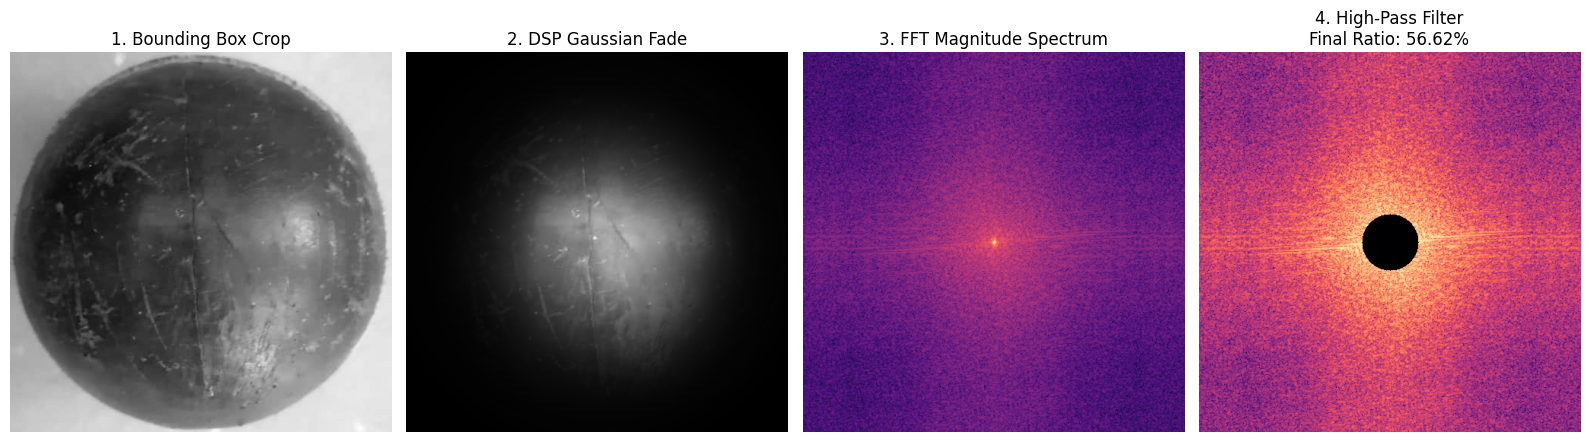

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: LOAD & SEGMENT (Phase 1 Logic)
# ==========================================
# Replace with your actual image path
image_path = '../data/raw/ball_2 shine side.jpg' 
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Isolate Green Grass & Invert to get the ball mask
lower_green = np.array([35, 20, 20])
higher_green = np.array([85, 255, 255])
bg_mask = cv2.inRange(hsv, lowerb=lower_green, upperb=higher_green)
mask = cv2.bitwise_not(bg_mask)

# Morphological Opening to clean pixel noise (The "Blade")
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
opened_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
contours, _ = cv2.findContours(opened_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("Error: Could not detect the ball. Check your green HSV thresholds.")
else:
    # Get largest contour and prune it geometrically (Douglas-Peucker)
    largest_contour = max(contours, key=cv2.contourArea)
    epsilon = 0.002 * cv2.arcLength(largest_contour, True)
    pruned_contour = cv2.approxPolyDP(largest_contour, epsilon, True)
    
    # Create Grayscale version for texture analysis
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ==========================================
    # STEP 2: BOUNDING BOX EXTRACTION
    # ==========================================
    # Extract the exact square boundary containing the entire ball
    x, y, w, h = cv2.boundingRect(pruned_contour)
    ball_crop = gray[y:y+h, x:x+w]
    
    # ==========================================
    # STEP 3: 2D GAUSSIAN WINDOWING
    # ==========================================
    rows, cols = ball_crop.shape
    center_x, center_y = cols // 2, rows // 2
    
    # Create a mathematical grid
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    
    # Calculate distance of every pixel from the center
    distance_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    
    # Sigma controls the fade. Radius/3 guarantees it fades to black at the edges.
    radius = min(cols, rows) / 2.0
    sigma = radius / 3.0  
    
    # Apply Gaussian formula to create the multiplier window
    gaussian_window = np.exp(-(distance_from_center**2) / (2 * sigma**2))
    
    # Multiply the ball crop by the window (Must convert to float64 for math)
    windowed_ball = ball_crop.astype(np.float64) * gaussian_window

    # ==========================================
    # STEP 4: FAST FOURIER TRANSFORM (FFT)
    # ==========================================
    # 1. Transform to Frequency Domain
    f_transform = np.fft.fft2(windowed_ball)
    
    # 2. Shift the low frequencies (smooth leather) to the center
    f_shift = np.fft.fftshift(f_transform)
    
    # 3. Create the visual Magnitude Spectrum (for plotting)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)
    
    # ==========================================
    # STEP 5: HIGH-PASS FILTER & ENERGY RATIO
    # ==========================================
    # Create a blank mask
    mask_fft = np.ones((rows, cols), np.uint8)
    crow, ccol = rows // 2 , cols // 2
    
    # Block the inner 15% (This mathematically deletes the smooth red leather)
    r = int(radius * 0.15) 
    cv2.circle(mask_fft, (ccol, crow), r, 0, -1)
    
    # Apply the High-Pass mask
    f_shift_filtered = f_shift * mask_fft
    
    # Calculate Energy Ratio
    total_energy = np.sum(np.abs(f_shift))
    high_freq_energy = np.sum(np.abs(f_shift_filtered))
    
    # The Final Mathematical Roughness Score
    fft_ratio = (high_freq_energy / total_energy) * 100 if total_energy > 0 else 0

    # ==========================================
    # STEP 6: VISUALIZATION
    # ==========================================
    print("--- SURFACE ROUGHNESS METRICS ---")
    print(f"High-Frequency Energy Ratio: {fft_ratio:.2f}%")
    print("(A higher % means more scuffs, scratches, and severe leather degradation)\n")

    plt.figure(figsize=(16, 5))
    
    plt.subplot(1, 4, 1)
    plt.title("1. Bounding Box Crop")
    plt.imshow(ball_crop, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title("2. DSP Gaussian Fade")
    plt.imshow(windowed_ball, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title("3. FFT Magnitude Spectrum")
    plt.imshow(magnitude_spectrum, cmap='magma')
    plt.axis('off')
    
    # Visualizing the filtered spectrum
    filtered_magnitude = 20 * np.log(np.abs(f_shift_filtered) + 1)
    plt.subplot(1, 4, 4)
    plt.title(f"4. High-Pass Filter\nFinal Ratio: {fft_ratio:.2f}%")
    plt.imshow(filtered_magnitude, cmap='magma')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()